In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))


# HMM / Kalman Regime Research v2

This notebook documents the public regime workflow used for the reported results in `README.md`.

## Scope

- Uses causal HMM re-estimation on rolling or expanding history only
- Applies causal Kalman filtering and post-weight regime scaling
- Writes saved search outputs under `outputs/regime_v2/`


## Data And Diagnostics

Load the shared utility notebook, import the supporting alpha helpers, and inspect the market panel before running the regime pipeline.

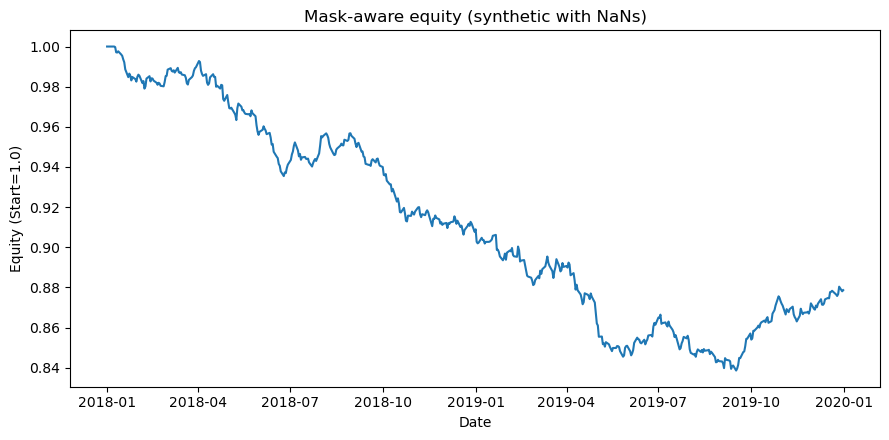

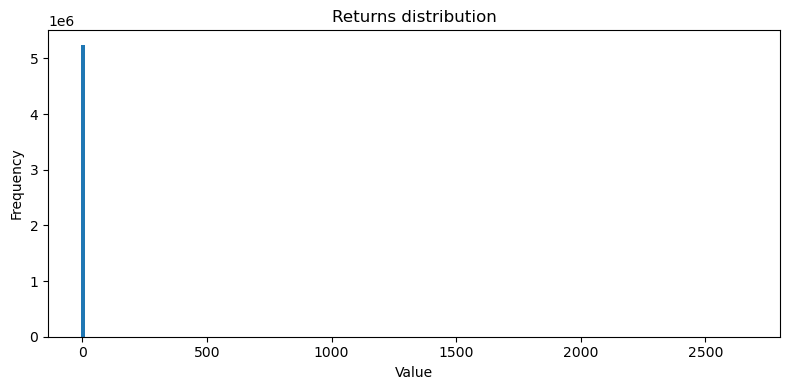

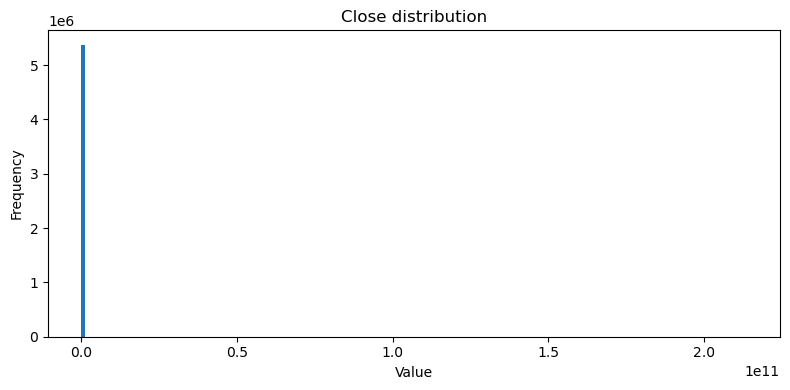

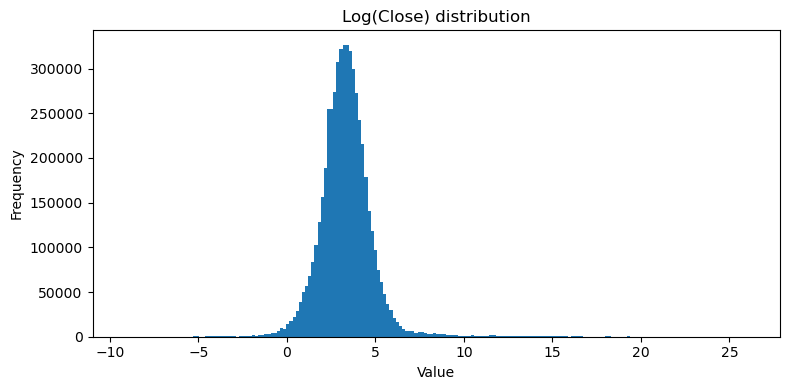

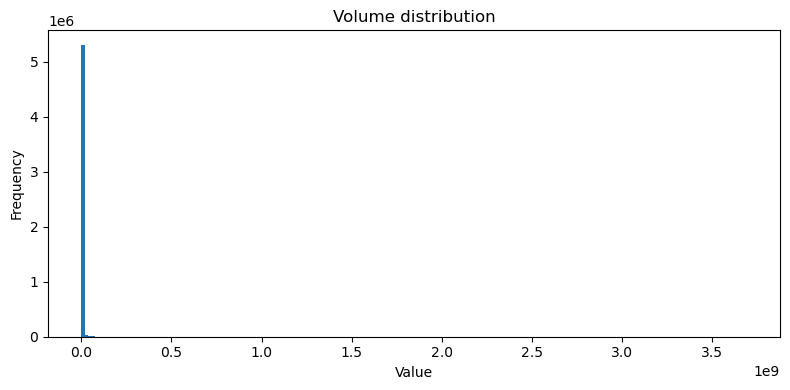

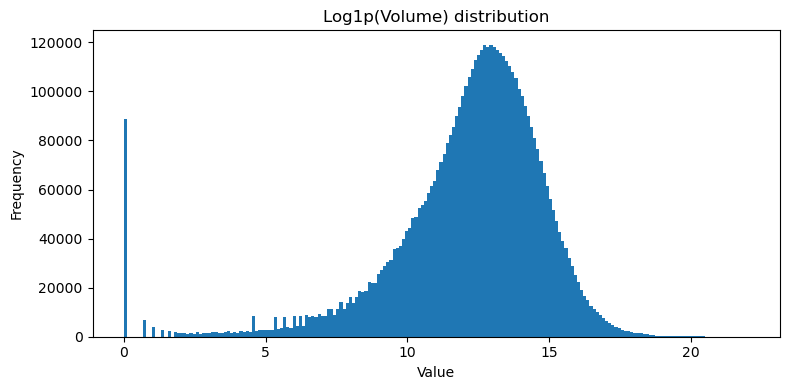

           count  missing_pct        min        1%           5%           25%  \
name                                                                            
returns  7372197    28.892459  -3.758620 -0.097927    -0.047847     -0.012431   
close    7372197    27.113966 -37.709606  0.890000     3.180000     12.112698   
volume   7372197    27.113966   0.000000  0.000000  1030.000000  59200.000000   

                   50%           75%           95%           99%  \
name                                                               
returns       0.000000  1.264287e-02  4.829209e-02  1.105958e-01   
close        26.712832  5.845000e+01  2.348000e+02  4.500000e+03   
volume   295500.000000  1.077900e+06  5.947203e+06  2.064960e+07   

                  max          mean           std         skew      kurtosis  \
name                                                                           
returns  2.665667e+03  2.160561e-03  1.450863e+00  1419.398938  2.334878e+06   
close    2.13

In [3]:
%run function_sets.ipynb
from us_equity.alphas.alpha_maco_safe import alpha_maco_plus, neutralize_by_group, vol_target_weights
import warnings
warnings.filterwarnings("ignore")


## Representative Regime Stack

This block combines the base EMA alpha with HMM-based regime scaling, a market-volatility conditioner, beta control, and a drawdown cap. It is the main reference implementation for the public `v2` path.

turnover:0.2771457984105154
{'ann_sharpe': 1.8073499359571097, 'cagr': 0.20680317925847724, 'tot_return': 3.6523191713788243, 'ann_vol': 0.10719569605979495, 'max_drawdown': -0.16862732652950085}


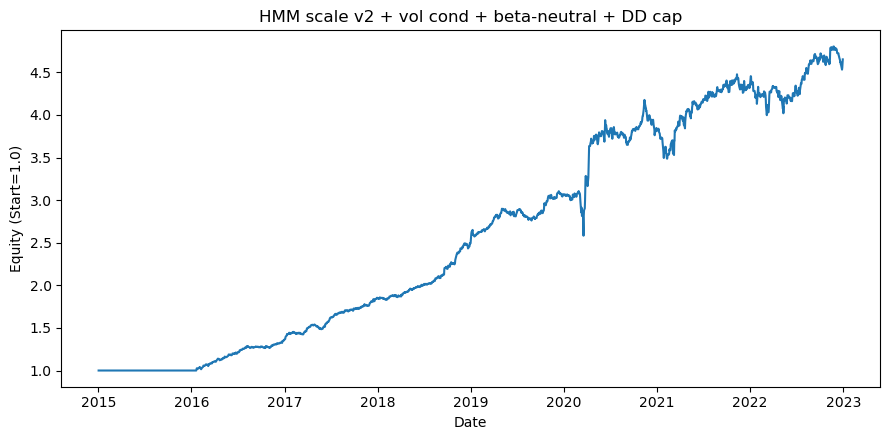

In [4]:
from us_equity.alphas.alpha_hmm_scale_v2 import hmm_overlay_scale_v2
from us_equity.overlays.risk_overlays import scale_by_market_vol, neutralize_to_market_beta, dd_exposure_scale
from us_equity.alphas.alpha_maco_plus_gpu import alpha_ema_crossover_gpu

base_kwargs = dict(
    close=close, volume=volume,
    fast_span=5, slow_span=10, atr_span=36, use_global_mad_winsor=True, mad_k=2,
    threshold_q=0.95, top_frac=0.05, min_keep=180,
    stale_span=5, stale_std_bp=1.0,
    hard_cap_abs_return=0.80,
    smooth_span=2,
)
alpha_base = alpha_ema_crossover_gpu(**base_kwargs)[0]

alpha_regime, diag = hmm_overlay_scale_v2(
    close=close,
    base_alpha_fn=lambda **kw: alpha_base,
    base_alpha_kwargs={},
    p_lo=0.45,
    p_hi=0.60,
    scale_ema_span=3,
    min_history=252,
    refit_every=5,
    train_window=756,
)

alpha_vol = scale_by_market_vol(alpha_regime, close, lookback=20, gamma=0.25, s_min=0.4)

tradable = build_tradable_mask(close, volume, 1.0, 1.0)
weights0 = make_weights(
    alpha_vol,
    gross_exposure=1.0,
    cap_per_name=0.01,
    neutralize=True,
    method="zscore",
    mask=tradable,
    min_names=50,
)
weights_beta_neut = neutralize_to_market_beta(weights0, close, lookback=60)

rets = close.pct_change(fill_method=None)
bt = backtest_long_short(weights0, rets, cost_bps=2)
dd_scale = dd_exposure_scale(
    bt["ret_net"].shift(1).fillna(0.0),
    window=252,
    dd_cut=-0.08,
    floor=0.4,
    halflife=20,
)
weights_final = weights0.mul(dd_scale, axis=0)

bt2 = backtest_long_short(weights_final, rets, cost_bps=2)
print(f"turnover:{float(bt['two_way_turnover'].mean())}")
print(performance_stats(bt2["ret_net"]))
plot_equity_curve(bt2["ret_net"], title="Representative v2 stack")


## Kalman Overlay Example

This block isolates the post-weight Kalman regime overlay. The objective here is not to maximize return in isolation, but to show how smoother exposure control can reduce whipsaw and improve portfolio stability.

turnover:0.1841170923652747
{'ann_sharpe': 1.4437824326831168, 'cagr': 0.0945881513049962, 'tot_return': 1.0941847979619768, 'ann_vol': 0.0640270622101981, 'max_drawdown': -0.1365069692064036}


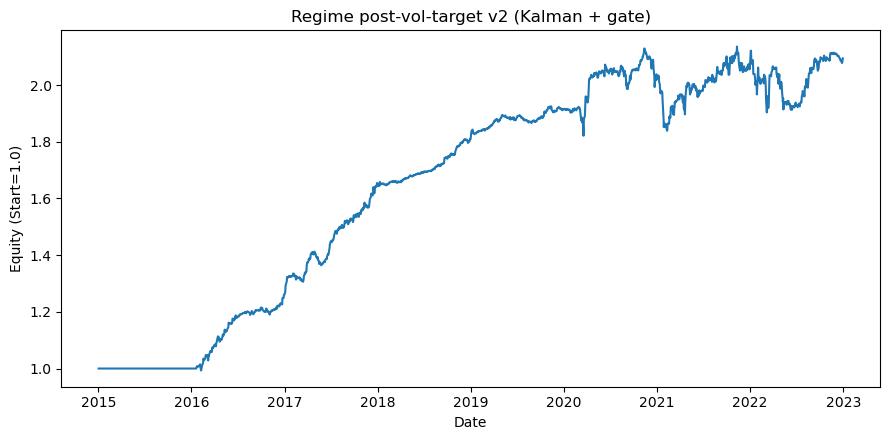

In [5]:
from us_equity.overlays.kalman_overlays_v2 import build_regime_scale_v2, apply_scale_to_weights

alpha = alpha_vol
tradable = build_tradable_mask(close, volume, 1.0, 1.0)
w0 = make_weights(
    alpha,
    gross_exposure=1.0,
    cap_per_name=0.005,
    neutralize=True,
    method="zscore",
    mask=tradable,
    min_names=50,
)
rets = close.pct_change(fill_method=None)

s, diag = build_regime_scale_v2(
    close,
    mode="dynamic",
    roll=252,
    q_lo=0.40,
    q_hi=0.60,
    hmm_min_history=252,
    hmm_refit_every=5,
    hmm_train_window=756,
    kf_q=5e-5,
    kf_r=5e-4,
    z_gate=2.5,
    floor=0.3,
)

w_final = apply_scale_to_weights(w0, s)

bt = backtest_long_short(w_final, rets, cost_bps=2)
print(f"turnover:{float(bt['two_way_turnover'].mean())}")
print(performance_stats(bt["ret_net"]))
plot_equity_curve(bt["ret_net"], title="Kalman post-scale overlay")


## Grid Search

The final block runs the joint search over base-alpha and regime parameters, then reports the best saved `v2` configuration used in the repository summary.

Grid search completed. Detailed progress logs were omitted from the public notebook for readability.


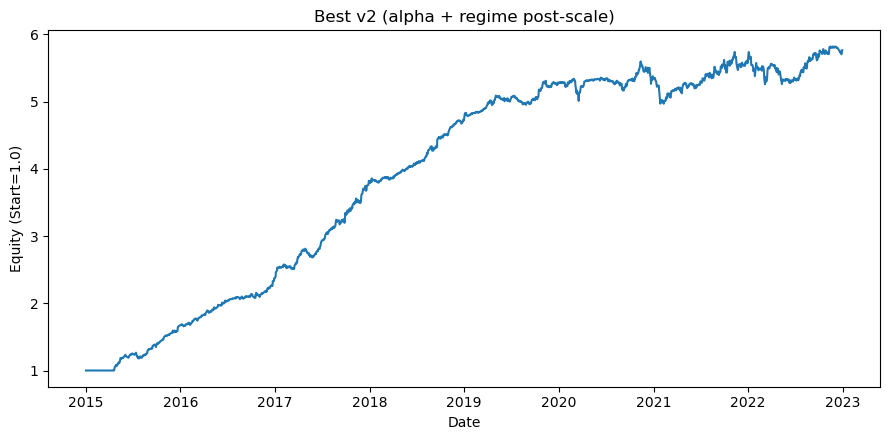

In [6]:
from us_equity.search.grid_search_with_regime import grid_search_with_post_weights
from us_equity.overlays.regime_post_scale_v2 import regime_post_scale_v2
from us_equity.search.quality_kinked import make_kinked_quality_fn
from us_equity.alphas.alpha_maco_plus_gpu import alpha_ema_crossover_gpu as alpha_fn

alpha_grid = {
    "fast_span": [4],
    "slow_span": [9],
    "atr_span": [30, 36],
    "threshold_q": [0.90, 0.95],
    "mad_k": [2.0, 1.8],
    "top_frac": [0.1, 0.15, 0.05],
    "min_keep": [180],
    "stale_span": [5],
    "stale_std_bp": [1.0],
    "hard_cap_abs_return": [0.8],
    "smooth_span": [2],
    "device": ["cuda"],
}

regime_grid = {
    "mode": ["dynamic"],
    "roll": [252, 126],
    "q_lo": [0.35, 0.40],
    "q_hi": [0.60, 0.65],
    "kf_q": [5e-5, 1e-4],
    "kf_r": [5e-4, 1e-3],
    "z_gate": [2.0, 2.5],
    "floor": [0.3, 0.4],
}

cfg = {
    "sharpe": {"range": (1.5, 1.8), "m_below": -8.0, "m_in": 1.5, "m_above": 0.2},
    "turnover": {"range": (0.25, 3), "higher_is_better": False, "m_below": -8.0, "m_in": 1.5, "m_above": 0.2},
    "max_weight": {"range": (0.05, 0.0), "higher_is_better": False, "m_below": -8.0, "m_in": 1.5, "m_above": 0.2},
    "tot_return": {"range": (2, 2.5), "m_below": -8.0, "m_in": 1.5, "m_above": 0.2},
}
quality_fn = make_kinked_quality_fn(cfg)

alpha_static = dict(close=close, volume=volume)
mw_kwargs = dict(
    gross_exposure=1.0,
    cap_per_name=0.01,
    neutralize=True,
    method="zscore",
    mask=build_tradable_mask(close, volume, 1.0, 1.0),
    min_names=50,
)
bt_kwargs = dict(cost_bps=2)
vt_kwargs = dict(target_ann_vol=0.10, lookback=60, max_leverage=3.0)

results_df, best = grid_search_with_post_weights(
    alpha_fn=alpha_fn,
    alpha_grid=alpha_grid,
    regime_post_grid=regime_grid,
    close=close,
    volume=volume,
    make_weights_fn=make_weights,
    make_weights_kwargs=mw_kwargs,
    backtest_fn=backtest_long_short,
    backtest_kwargs=bt_kwargs,
    vol_target_fn=vol_target_weights,
    vol_target_kwargs=vt_kwargs,
    post_weights_fn=regime_post_scale_v2,
    post_weights_base_kwargs=dict(
        close=close,
        hmm_min_history=252,
        hmm_refit_every=5,
        hmm_train_window=756,
    ),
    returns=close.pct_change(fill_method=None),
    quality_fn=quality_fn,
    alpha_static_kwargs=alpha_static,
    progress=True,
    save_csv=str(REPO_ROOT / "outputs" / "regime_v2" / "grid_results_regime_v2.csv"),
    return_artifacts=True,
)

print("Best alpha params:", best["alpha_params"])
print("Best regime params:", best["regime_params"])
print("Best metrics:", best["metrics"])
plot_equity_curve(best["ret_net"], title="Best saved v2 configuration")


## Best Saved Configuration

The best saved `v2` grid-search result combines a fast EMA trend signal with tighter tail selection and dynamic regime scaling.

| Metric | Value |
| --- | ---: |
| Sharpe | `2.73` |
| CAGR | `23.9%` |
| Total Return | `4.76x` |
| Max Drawdown | `-11.2%` |
| Avg Turnover | `0.167` |

Key settings in the best saved run: fast/slow EMA `4/9`, `atr_span=36`, `threshold_q=0.95`, `top_frac=0.05`, dynamic regime thresholds, causal Kalman filtering, and `floor=0.4`.